# Analisi di un disastro

Questo è un notebook a scopo didattico utile a presentazioni e workshop di introduzione in italiano al tema del machine learning. 

Il problema che ci viene posto è di creare un modello matematico utile a predire la sopravvivenza di un individuo al disastro del titanic date alcune caratteristiche (features) come, età, sesso, nome, costo del biglietto, classe, etc. 
Come in ogni problema di machine learning avremo a disposizione due insiemi di dati, uno di addestramento (Training) in cui è nota l'informazione obiettivo (target) ovvero se l'individuo sia di fatto sopravvissuto o no. Il secondo, detto di Test, con cui dovremo sperimentare il modello che avremo creato (e addestrato) per poi utilizzare le sue predizioni per un confronto con i dati reali, noti a Kaggle ma ignoti a noi. Da questo confronto avremo una valutazione finale del nostro lavoro. 


In termini più tecnici il problema è di tipo Supervised perché ci vengono forniti degli esempi (appunto il set di Training) e, in particolare, è un problema di classificazione binaria, perché ci viene chiesto di stabilire a quale classe tra due (Sopravvissuti e non Sopravvissuti) appartenga un individuo non precedentemente noto di cui sono però date le caratteristiche.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/train.csv


 Per prima cosa carichiamo i dati di addestramento e quelli di test e visualizziamo le prime 5 righe del dataframe dei dati di addestramento (Training):

In [2]:
df = pd.read_csv("../input/titanic/train.csv")
test_df = pd.read_csv("../input/titanic/test.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Ecco una breve spiegazione dei dati forniti:
* PassengerId: è un numero intero che identifica univocamente un/una passeggero/a;
* Survived: ci dice se quel passeggero sia sopravvisuto (se vale 1) oppure no (se vale 0);
* Pclass: ci dice il numero di classe del biglietto. Ad esempio prima classe (1), seconda classe (2), etc.;
* Name: il nome del/della passeggero/a
* Sex: se uomo o donna;
* Age: l'età espressa in anni;
* SibSp: il numero di fratelli/sorelle/coniuge a bordo;
* Parch: il numero di genitori/figli a bordo;
* Ticket: il numero del biglietto;
* Fare: il costo del biglietto;
* Cabin: il numero della cabina;
* Embarked: il porto di imbarco (C = Cherbourg, Q = Queenstown, S = Southampton)



In [3]:

print('Cabin null values:',df['Cabin'].isna().sum())
print('Pclass null values:',df['Pclass'].isna().sum())
print('Name null values:',df['Name'].isna().sum())
print('Ticket null values:',df['Ticket'].isna().sum())
print('Fare null values:',df['Fare'].isna().sum())
print('Survived null values:',df['Survived'].isna().sum())
print('Embarked null values:',df['Embarked'].isna().sum())
print('SibSp null values:',df['SibSp'].isna().sum())
print('Parch null values:',df['Parch'].isna().sum())
print('Age null values:',df['Age'].isna().sum())


Cabin null values: 687
Pclass null values: 0
Name null values: 0
Ticket null values: 0
Fare null values: 0
Survived null values: 0
Embarked null values: 2
SibSp null values: 0
Parch null values: 0
Age null values: 177


Ci dobbiamo ricordare che Cabin, Age e Embarked hanno dei valori non validi. Inoltre dobbiamo assumere che anche stringe non strutturate come Name o Ticket possano contenere degli errori, vedremo come provare a gestire questi aspetti.

In [4]:
df.dropna(subset=['Embarked'],inplace=True)

Consideriamo anche il fatto che ci stiamo confrotando con diversi tipi di dati:
* Categorici: ovvero che possono assumere un numero ben definito di valori. Ad esempio il dato Pclass può assumere solo i valori (1,2,3). Le categorical features di questo problema sono: *Survived* (0 oppure 1); *Pclass* (1,2 o 3), *Sex* (0 o 1),  Embarked (C, Q o S)
* Numerici: Age, Fare, SibSp, Parch,
* Testi: Name, Ticket, Cabin
        

Il nostro obiettivo è addestrare un modello che sia in grado di predire, date le caratteristiche descritte di un imbarcato, se questo sia sopravvisuto o meno al disastro del titanic. 
Vediamo ora come si distribuiscono i dati a nostra disposizione:

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,712.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.642093,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,14.492933,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,20.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


([<matplotlib.patches.Wedge at 0x7f72e0ccba58>,
 [Text(-0.3970459950615895, 1.0258433008045393, 'Not Survived'),
  Text(0.3970459950615891, -1.0258433008045393, 'Survived')],
 [Text(-0.21657054276086699, 0.5595508913479305, '61.8%'),
  Text(0.21657054276086676, -0.5595508913479305, '38.2%')])

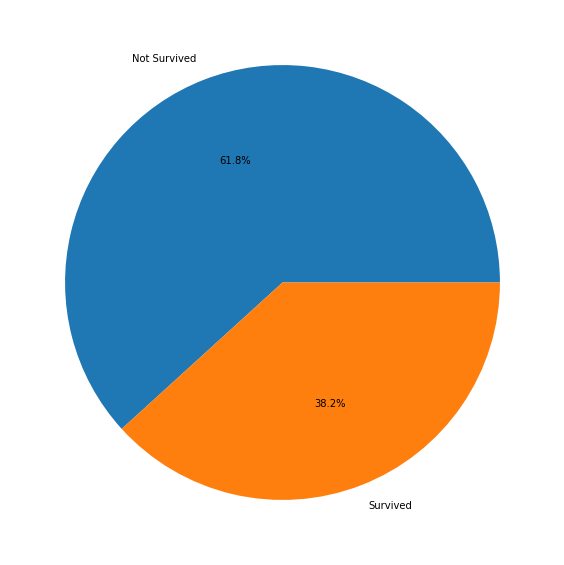

In [6]:
fig,ax1=plt.subplots(1,1,figsize=(10,10))
labels = ['Not Survived','Survived']
v=df['Survived']
ax1.pie(v.value_counts().loc[[0,1]],labels = labels,autopct='%1.1f%%',)


Una prima trasformazione utile sui dati consiste nel rendere numerici o categorie dei dati testuali. Ad esempio, il genere sessuale del passeggero, espresso come testo possiamo trasformarlo in due valori: 0 se maschile 1 se femminile. 

Per quanto riguarda il porto di imbarco possiamo fare la seguente trasformazione:
* 0 per chi si imbarca da Cherbourg
* 1 per chi si imbarca da Queenstown
* 2 per chi si imbarca da Southempton

In [7]:
df['cSex']=[1 if c=='female' else 0 for c in df['Sex']]
df['cEmbarked'] = df.Embarked.map( {'C': 0, 'Q': 1, 'S': 2} ).astype(int)

test_df['cSex']=[1 if c=='female' else 0 for c in test_df['Sex']]
test_df['cEmbarked'] = test_df.Embarked.map( {'C': 0, 'Q': 1, 'S': 2} ).astype(int)

A questo punto possiamo verificare l'esistenza di una correlazione tra i dati iniziali di cui disponiamo. In statistica si dice che due variabili sono correlate se al crescere di una cresce/decresce l'altra o viceversa. Ovvero se esiste una legge che in qualche modo mette in relazione i due valori. 
La correlazione tra due variabili può essere quindi: diretta (o positiva), ad esempio all'aumentare di sigarette fumate aumenta la probabilità di contrarre malattie; o indiretta (anche detta inversa o negativa): all'aumentare nel tempo delle emissioni che producono effetto serra si sperimenta una riduzione dei ghiacciai. 

Il grado di correlazione tra due variabili viene espresso tramite l'indice di correlazione. Il valore che esso assume è compreso tra −1 (correlazione inversa) e 1 (correlazione diretta e assoluta), con un indice pari a 0 corrisponde ad un'assenza di correlazione; il valore nullo dell'indice non implica, tuttavia, che le variabili siano indipendenti.

Per questo esempio utilizzeremo l'indice di Pearson, dato dalla seguente formula:

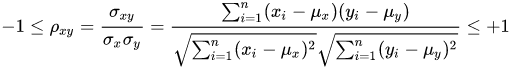



e li mostreremo graficamente attraverso una mappa di calore (heatmap) nella quale ad ogni coppia di variabili corrisponderà un colore che sarà tanto più chiaro quanto più alta sarà la correlazione tra le due variabili e, viceversa, tanto più scuro quanto più basoa (negativamente) sarà questo valore.

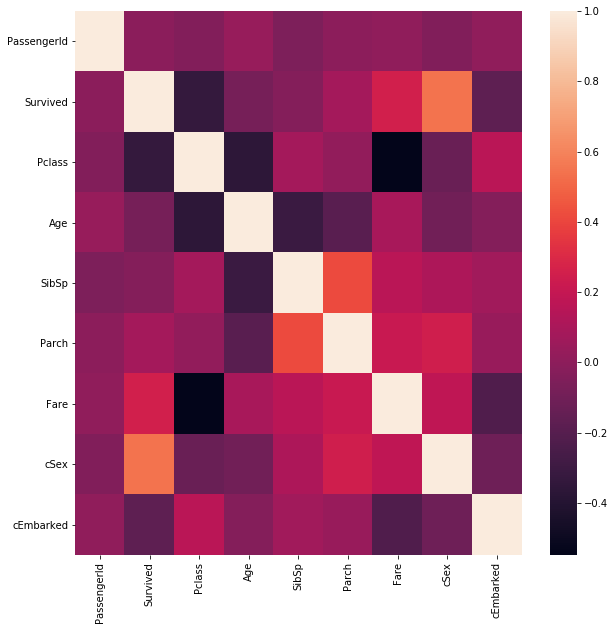

In [8]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(corr, 
        xticklabels=corr.columns,
        yticklabels=corr.columns, ax = ax)

Come possiamo notare esiste una feature che mostra una forte correlazione con la sopravvivenza, ovvero la Classe del biglietto. In particolare la correlazione è negativa il che significa che al crescere della classe si riduce la probabilità di sopravvivenza. Insomma i dati ci stanno già comunicando che la prima classe è sopravvisuta molto di più della terza. Come sappiamo dalla storia questo è probabilmente spiegabile per l'ordine di accesso alle scialuppe che ha evidentemente preferito le prime classi alle terze. 

Inoltre dai dati sembrerebbe che una maggiore età sia coincisa con una minore classe. Come a dire che il costo della prima classe, e quindi l'accesso a certi privilegi, fosse di maggiore appannaggio per individui maturi, i quali, sempre secondo questa prima vista dei dati, avevano tipicamente meno familiari a bordo (fratelli/sorelle o genitori).
Questo spiega la non così netta correlazione tra l'età e la sopravvivenza. Evidentemente la giovane età, in teoria predisponente ad una maggiore possibilità di sopravvivenza, in realtà si è tradotta in una minore possibilità di accesso alla prima classe, che si è dimostrata la caratteristica apparantemente realmente premiante in termini di sopravvivenza.

Osserviamo inoltre una correlazione tra il genere sessuale del passeggero e la sopravvivenza. In particolare le donne sembrerebbero avere una maggiore probabilità di sopravvivenza. Ancora una volta questo potrebbe essere spiegabile per la prassi di aver dato la precedenza all'accesso delle scialuppe a questa categoria di passeggeri. 

## Sopravvivenza per Genere

Andiamo a creare dei grafici che mostrino la distribuzione di donne e uomini nella diverse classi di nostro interesse. Vedremo quindi:
* le percentuali di uomini e donne tra i non sopravvissuti;
* le percentuali di uomini e donne tra i sopravvissuti;
* le percentuali di sopravvissuti tra gli uomini;
* le percentuali di non sopravvissuti tra le donne.


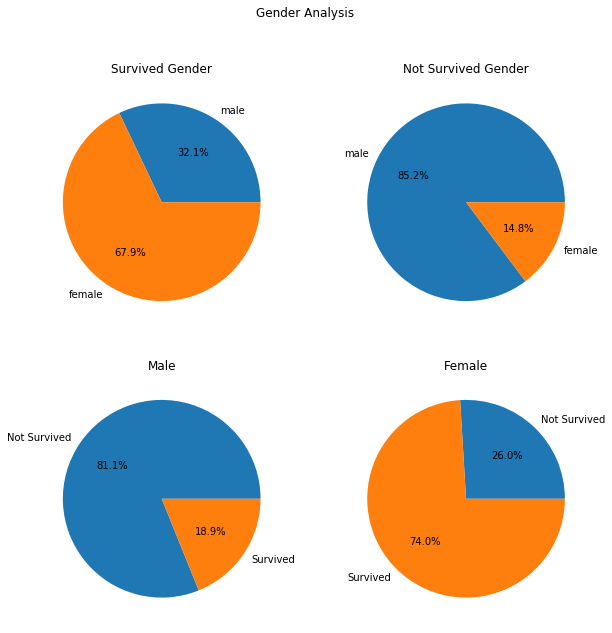

In [9]:
fig,((ax1,ax2),(ax3,ax4))=plt.subplots(2,2,figsize=(10,10))
labels = ['male','female']
v=df[df['Survived']==1]['cSex']
ax1.pie(v.value_counts().loc[[0,1]],labels = labels,autopct='%1.1f%%',)
ax1.set_title('Survived Gender')

dead_sex=df[df['Survived']==0]['cSex']
ax2.pie(dead_sex.value_counts().loc[[0,1]],labels=labels,autopct='%1.1f%%',)
ax2.set_title('Not Survived Gender')

ax3.pie(df[df['cSex']==0]['Survived'].value_counts().loc[[0,1]],labels=['Not Survived','Survived'],autopct='%1.1f%%',)
ax3.set_title('Male')

ax4.pie(df[df['cSex']==1]['Survived'].value_counts().loc[[0,1]],labels=['Not Survived','Survived'],autopct='%1.1f%%',)
ax4.set_title('Female')
fig.suptitle('Gender Analysis')
plt.show()



## Sopravvivenza per Classe

Analogamente vediamo come la sopravvivenza si distribuisca tra le classi prima, seconda e terza e come all'interno di ogni classe si distribuiscano i sopravvissuti e non.

Text(0.5, 1.0, 'Not Survived Class')

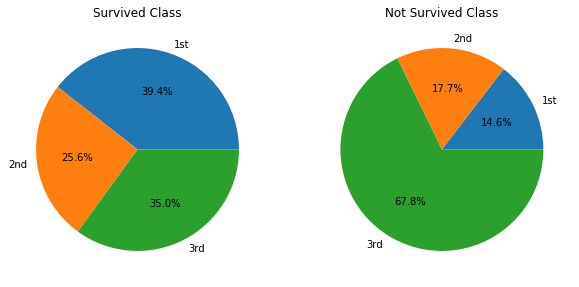

In [10]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,10))
v=df[df['Survived']==1]['Pclass']
ax1.pie(v.value_counts().loc[[1,2,3]],labels=['1st','2nd','3rd'],autopct='%1.1f%%',)
ax1.set_title('Survived Class')

v=df[df['Survived']==0]['Pclass']
ax2.pie(v.value_counts().loc[[1,2,3]],labels=['1st','2nd','3rd'],autopct='%1.1f%%',)
ax2.set_title('Not Survived Class')



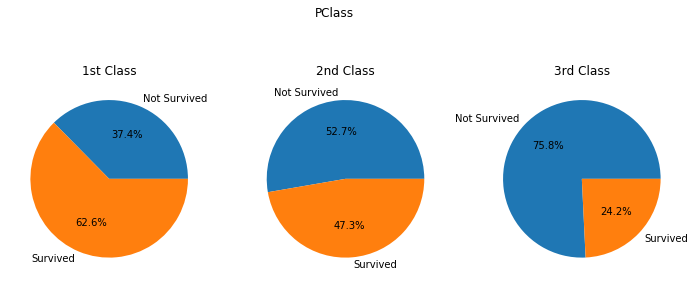

In [11]:
fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(12,5))
ax1.pie(df[df['Pclass']==1]['Survived'].value_counts().loc[[0,1]],labels=['Not Survived','Survived'],autopct='%1.1f%%',)
ax1.set_title('1st Class')

ax2.pie(df[df['Pclass']==2]['Survived'].value_counts().loc[[0,1]],labels=['Not Survived','Survived'],autopct='%1.1f%%',)
ax2.set_title('2nd Class')

ax3.pie(df[df['Pclass']==3]['Survived'].value_counts().loc[[0,1]],labels=['Not Survived','Survived'],autopct='%1.1f%%',)
ax3.set_title('3rd Class')


fig.suptitle('PClass')
plt.show()

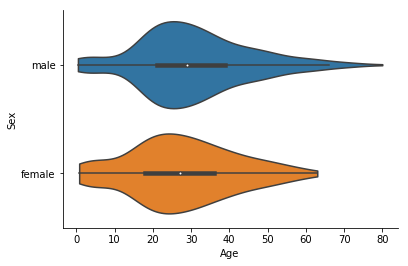

In [12]:
df_nn = df[pd.notnull(df['Age'])]
import seaborn as sns
sns.violinplot(df_nn['Age'], df_nn['Sex'], cut=0.) #Variable Plot
sns.despine()

## Sopravvivenza per porto

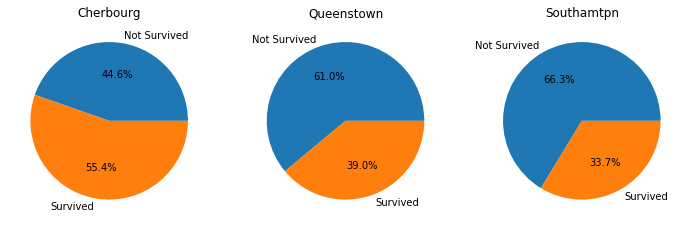

In [13]:
fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(12,5))
ax1.pie(df[df['cEmbarked']==0]['Survived'].value_counts().loc[[0,1]],labels=['Not Survived','Survived'],autopct='%1.1f%%',)
ax1.set_title('Cherbourg')

ax2.pie(df[df['cEmbarked']==1]['Survived'].value_counts().loc[[0,1]],labels=['Not Survived','Survived'],autopct='%1.1f%%',)
ax2.set_title('Queenstown')

ax3.pie(df[df['cEmbarked']==2]['Survived'].value_counts().loc[[0,1]],labels=['Not Survived','Survived'],autopct='%1.1f%%',)
ax3.set_title('Southamtpn')

plt.show()

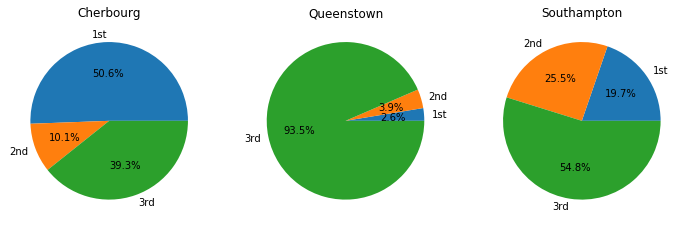

In [14]:
fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(12,5))
ax1.pie(df[df['cEmbarked']==0]['Pclass'].value_counts().loc[[1,2,3]],labels=['1st','2nd','3rd'],autopct='%1.1f%%',)
ax1.set_title('Cherbourg')

ax2.pie(df[df['cEmbarked']==1]['Pclass'].value_counts().loc[[1,2,3]],labels=['1st','2nd','3rd'],autopct='%1.1f%%',)
ax2.set_title('Queenstown')

ax3.pie(df[df['cEmbarked']==2]['Pclass'].value_counts().loc[[1,2,3]],labels=['1st','2nd','3rd'],autopct='%1.1f%%',)
ax3.set_title('Southampton')

plt.show()

## Prime considerazioni

Abbiamo verificato che Sesso e Classe del biglietto sono informazioni improtanti nella valutazione di una probabilità di sopravvivenza. Mentre possiamo già intuire che il porto di partenza non porti un significativo contributo informatico perché strettamente legato ad un'altra informazione della quale già teniamo conto: la classe del biglietto. 

Sappiamo che anche l'età ha costituito un fattore determinante nella probabilità di sopravvivere al disastro del Titanic. Il problema è che questo dato ha molti dati mancanti e così com'è avremmo difficoltà ad utilizzarlo nell'addestramento di un modello di predizione.

## Il problema dei mancanti

L'età dei passeggeri è sicuramente un discriminante utile ma abbiamo diversi valori di età mancanti nei dati di training.
Possiamo gestire questo aspetto sostituendo i valori mancanti con delle ipotesi in modo da poter comunque addestrare un modello sensibile al dato di età, quando a disposizione. 

Un modo possibile è quello di osservare la relazione tra il dato di età e le altre feature a disposizione. Dalla matrice di correlazione possiamo osservare che l'età mostra una correlazione con le feature *Pclass* e *Sex* come mostrato dal seguente diagramma.

In [15]:
df[['Sex','Age']].groupby('Sex').mean()

,Age
Sex,
female,27.745174
male,30.726645


com'è possibile osservare i passeggeri femmnili hanno in media 3 anni in meno degli uomini

In [16]:
df[['Pclass','Age']].groupby('Pclass').mean()

,Age
Pclass,
1,38.105543
2,29.877630
3,25.140620


i passeggeri della terza classe hanno in media 13 anni in meno di quelli della terza classe

/opt/conda/lib/python3.6/site-packages/seaborn/axisgrid.py:243: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


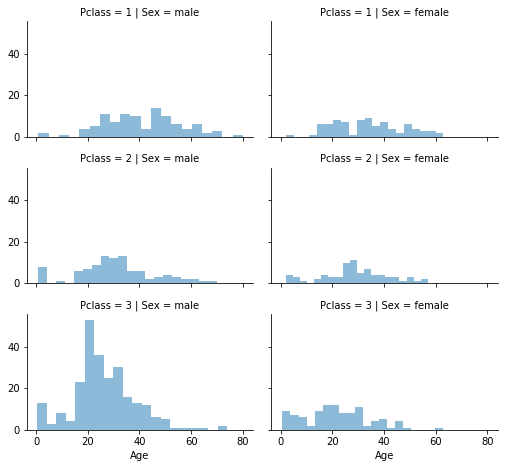

In [17]:
grid = sns.FacetGrid(df, row='Pclass', col='Sex', size=2.2, aspect=1.6)
grid.map(plt.hist, 'Age', alpha=.5, bins=20)
grid.add_legend()

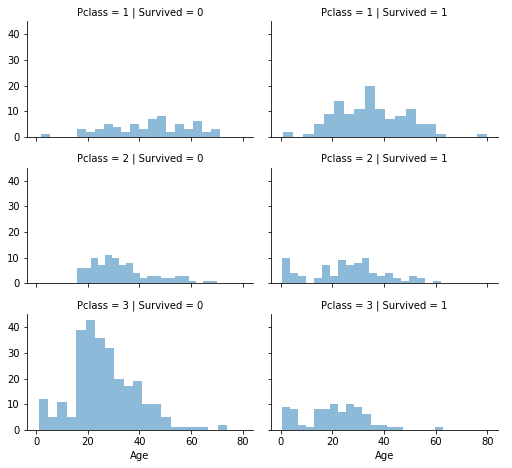

In [18]:
grid = sns.FacetGrid(df, row='Pclass', col='Survived', size=2.2, aspect=1.6)
grid.map(plt.hist, 'Age', alpha=.5, bins=20)
grid.add_legend()

In [19]:
#prendendo spunto dal Kernel https://www.kaggle.com/startupsci/titanic-data-science-solutions possiamo fare come segue:
combine = [df,test_df]
guess_ages = np.zeros((2,3))
for dataset in combine:
    for i in range(0, 2):
        for j in range(0, 3):
            guess_df = dataset[(dataset['cSex'] == i) & (dataset['Pclass'] == j+1)]['Age'].dropna()
            age_guess = guess_df.median()
            guess_ages[i,j] = int( age_guess/0.5 + 0.5 ) * 0.5
        
    for i in range(0, 2):
        for j in range(0, 3):
            dataset.loc[ (dataset.Age.isnull()) & (dataset.cSex == i) & (dataset.Pclass == j+1),\
                    'Age'] = guess_ages[i,j]

    dataset['Age'] = dataset['Age'].astype(int)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,cSex,cEmbarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S,0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S,1,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,1,2
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S,0,2


in pratica abbiamo sostitito i valori mancanti con le medie delle età calcolate per le tre classi su uomini e donne, avendole calcolate sulla intera quantità di dati di training e di test.

In [20]:
pd.DataFrame(guess_ages,columns=['1stClass','2ndClass','3rdClass'],index=['male','female'])

,1stClass,2ndClass,3rdClass
male,42.0,28.0,24.0
female,41.0,24.0,22.0


# Prima prova di addestramento

Dopo aver fatto una prima analisi dei dati proviamo a creare un primo modello capace di predire, note le caratteristiche di un nuovo individuo, se questo sopravvivrà o no al disastro del Titanic. 
Esistono molti modelli che è possibile addestrare per questo tipo di problema (Supervised), noi utilizzeremo gli Alberi di Decisione o Decision Tree.
Per valutare la prestazione del modello addestrato faremo ricorso ad una metrica molto semplice ovvero l’accuratezza. Calcoleremo quindi la percentuale di previsioni corrette rispetto alla totalità.
 
Un albero di decisione è una struttura che guida alla classificazione di dati che viene costruita automaticamente attraverso specifici algoritmi. 
A partire da un elemento iniziale (radice) i dati a disposizione vengono suddivisi in due insiemi secondo una condizione da valutare su una delle caratteristiche date. Quale feature scegliere e quale condizione imporre viene valutato automaticamente dall’algoritmo utilizzando diverse strategie che tengono conto di quanto «efficaciemente» i dati vengano separato (i.e. Information Gain).


In [21]:
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.tree import export_graphviz
from sklearn.model_selection import cross_val_score

train_features = df[['Pclass','cSex','cEmbarked','Age','SibSp','Parch']]

train_target = df[['Survived']]

In [22]:
import matplotlib.pyplot as plt
from subprocess import call
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
    
    
def display_tree(feats, p1):
    X_train, X_test, y_train, y_test = train_test_split(feats, train_target, test_size=0.20, random_state=42)
    model = tree.DecisionTreeClassifier()
    model.fit(X_train,y_train)
    results = model.predict(X_test)
    acc = accuracy_score(results,y_test)
    export_graphviz(model, out_file='tree.dot',
                feature_names = p1,
                class_names=['Non Sopravvissuto','Sopravvissuto'],
                rounded = True, proportion = False, 
                precision = 2, filled = True, impurity = False)
    call(['dot', '-Tpng', 'tree.dot', '-o', 'tree.png', '-Gdpi=600'])

    plt.figure(figsize = (14, 18))
    plt.imshow(plt.imread('tree.png'))
    plt.axis('off');
    plt.show();
    print(acc)


con una sola feature, ovvero la classe del biglietto, si ottiene in modo automatico questo semplice modello che essenzialmente, osservando i dati, decreta sopravvissuto solo chi appartiene alla prima classe

Questo modello ottiene in media il 67% di accuratezza

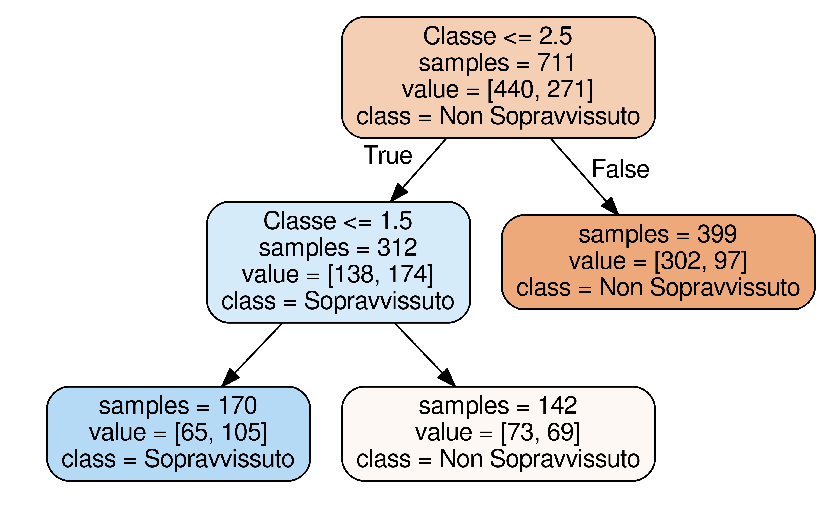

0.6910112359550562


In [23]:
display_tree(df[['Pclass']],['Classe'])

Analizzando insieme la Classe ed il Sesso del passeggero si ottiene automaticamente questo modello che, osservando i dati, decreta come sopravvissuto solo le donne appartenenti alla prima e seconda classe
Questo modello ottiene in media il 77% di accuratezza 

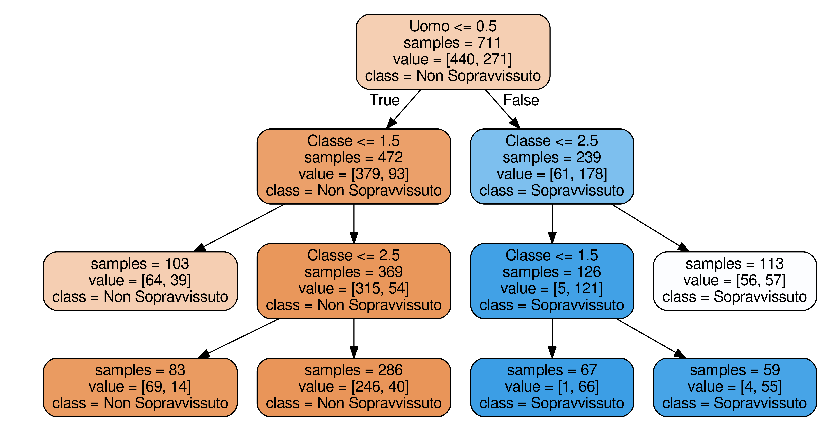

0.797752808988764


In [24]:
display_tree(df[['cSex','Pclass']],['Uomo','Classe'])

Aggiungendo anche l’età il modello generato diventa troppo vasto ed una sua visualizzazione priva di senso. 
In media questo modello ottiene l’ 80% di accuratezza.

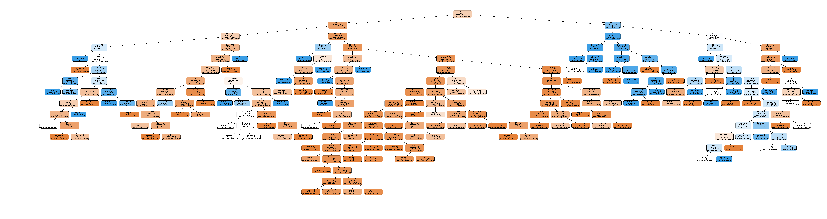

0.8202247191011236


In [25]:
display_tree(df[['cSex','Pclass','Age']],['Uomo','Classe','Età'])

# Creazione di nuove Feature

com'è possibile notare visualizzando i nomi dei passeggeri, questi sono completi di titolo, possiamo estrarre ed isolare questa informazione per analizzarla. La seguente tabella mostra come i titoli si distribuiscano tra i sopravvissuti e non

In [26]:
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

pd.crosstab(df['Survived'], df['Title'])

Title,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Survived,,,,,,,,,,,,,,,,,
0,1,1,0,1,4,1,0,1,17,55,0,0,436,26,0,6,0
1,0,1,1,0,3,0,1,1,23,126,2,1,81,98,1,0,1


come suggerito in https://www.kaggle.com/startupsci/titanic-data-science-solutions possiamo fare una sintesi dei diversi titoli in: "Master", "Miss", "Mr", "Mrs" e "Rare" con cui indichiamo tutti gli altri titoli.

In [27]:
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
 	'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')
    
df[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

,Title,Survived
0,Master,0.575000
1,Miss,0.701087
2,Mr,0.156673
3,Mrs,0.792000
4,Rare,0.347826


e trasformiamo queste categorie in numeri

In [28]:
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
for dataset in combine:
    dataset['cTitle'] = dataset['Title'].map(title_mapping)
    dataset['cTitle'] = dataset['cTitle'].fillna(0)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,cSex,cEmbarked,Title,cTitle
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S,0,2,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C,1,0,Mrs,3
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S,1,2,Miss,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,1,2,Mrs,3
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S,0,2,Mr,1


In [29]:
for dataset in combine:    
    dataset.loc[ dataset['Age'] <= 5, 'cAge'] = 0
    dataset.loc[(dataset['Age'] > 5) & (dataset['Age'] <= 10), 'cAge'] = 1
    dataset.loc[(dataset['Age'] > 10) & (dataset['Age'] <= 20), 'cAge'] = 2
    dataset.loc[(dataset['Age'] > 20) & (dataset['Age'] <= 35), 'cAge'] = 3
    dataset.loc[(dataset['Age'] > 35) & (dataset['Age'] <= 45), 'cAge'] = 4
    dataset.loc[(dataset['Age'] > 45) & (dataset['Age'] <= 55), 'cAge'] = 5
    dataset.loc[ dataset['Age'] > 55, 'cAge'] = 6
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,cSex,cEmbarked,Title,cTitle,cAge
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S,0,2,Mr,1,3.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C,1,0,Mrs,3,4.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S,1,2,Miss,2,3.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,1,2,Mrs,3,3.0
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S,0,2,Mr,1,3.0


In [30]:
for dataset in combine:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] 
    
for dataset in combine:
    dataset['IsAlone'] = 0
    dataset.loc[dataset['FamilySize'] == 1, 'IsAlone'] = 1

df[['IsAlone', 'Survived']].groupby(['IsAlone'], as_index=False).mean()

,IsAlone,Survived
0,0,0.344780
1,1,0.552795


In [31]:
for dataset in combine:
    dataset.loc[ dataset['Fare'] <= 7.91, 'cFare'] = 0
    dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'cFare'] = 1
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31), 'cFare']   = 2
    dataset.loc[ dataset['Fare'] > 31, 'cFare'] = 3
    #dataset['cFare'] = dataset['cFare'].astype(int)

#df = df.drop(['FareBand'], axis=1)
combine = [df, test_df]
    
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,cSex,cEmbarked,Title,cTitle,cAge,FamilySize,IsAlone,cFare
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S,0,2,Mr,1,3.0,1,1,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C,1,0,Mrs,3,4.0,1,1,3.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S,1,2,Miss,2,3.0,0,0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,1,2,Mrs,3,3.0,1,1,3.0
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S,0,2,Mr,1,3.0,0,0,1.0
5,6,0,3,"Moran, Mr. James",male,25,0,0,330877,8.4583,NaN,Q,0,1,Mr,1,3.0,0,0,1.0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S,0,2,Mr,1,5.0,0,0,3.0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.0750,NaN,S,0,2,Master,4,0.0,4,0,2.0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,NaN,S,1,2,Mrs,3,3.0,2,0,1.0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,NaN,C,1,0,Mrs,3,2.0,1,1,2.0


In [32]:
for dataset in combine:
    dataset['Age*Class'] = dataset.cAge * dataset.Pclass

df.loc[:, ['Age*Class', 'Age', 'Pclass']].head(10)

,Age*Class,Age,Pclass
0,9.0,22,3
1,4.0,38,1
2,9.0,26,3
3,3.0,35,1
4,9.0,35,3
5,9.0,25,3
6,5.0,54,1
7,0.0,2,3
8,9.0,27,3
9,4.0,14,2


In [33]:
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score

feats =df[['cSex','Pclass','IsAlone','cTitle','Age*Class','FamilySize','cAge']]
X_train, X_test, y_train, y_test = train_test_split(feats, train_target, test_size=0.20, random_state=42)
model = tree.DecisionTreeClassifier()
model.fit(X_train,y_train)
res = model.predict(X_test)
acc = accuracy_score(res,y_test)
recall = recall_score(res,y_test)
precision = precision_score(res,y_test)
print(acc,recall,precision)    

0.8258426966292135 0.7638888888888888 0.7971014492753623


In [34]:
feats =df[['cSex','Pclass','cAge','IsAlone','cTitle','Age*Class','FamilySize']]
X_train, X_test, y_train, y_test = train_test_split(feats, train_target, test_size=0.20, random_state=42)
model = SVC()
model.fit(X_train,y_train.values.ravel())
res = model.predict(X_test)
acc = accuracy_score(res,y_test.values.ravel())
recall = recall_score(res,y_test)
precision = precision_score(res,y_test)
print(acc,recall,precision) 

0.797752808988764 0.726027397260274 0.7681159420289855


In [35]:
feats =df[['cSex','Pclass','cAge','IsAlone','cTitle','Age*Class','FamilySize']]
X_train, X_test, y_train, y_test = train_test_split(feats, train_target, test_size=0.20, random_state=42)
model = KNeighborsClassifier(n_neighbors = 3)
model.fit(X_train,y_train.values.ravel())
res = model.predict(X_test)
acc = accuracy_score(res,y_test)
recall = recall_score(res,y_test)
precision = precision_score(res,y_test)
print(acc,recall,precision)     

0.7921348314606742 0.75 0.6956521739130435


In [36]:
feats =df[['cSex','Pclass','cAge','IsAlone','cTitle','Age*Class','FamilySize']]
X_train, X_test, y_train, y_test = train_test_split(feats, train_target, test_size=0.20, random_state=42)
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train,y_train.values.ravel())
res = model.predict(X_test)
acc = accuracy_score(res,y_test)
recall = recall_score(res,y_test)
precision = precision_score(res,y_test)
print(acc,recall,precision) 

0.8258426966292135 0.7638888888888888 0.7971014492753623


In [37]:
acc = accuracy_score([0]*len(y_test),y_test)
recall = recall_score([0]*len(y_test),y_test)
print(acc,recall)

0.6123595505617978 0.0


/opt/conda/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [38]:
def dummy(X):
    return [0 if i ==0 else 1 for i in X['cSex']]
        

In [39]:
acc = accuracy_score(dummy(X_test),y_test)
recall = recall_score(dummy(X_test),y_test)
precision = precision_score(dummy(X_test),y_test)
print(acc,recall,precision) 



0.797752808988764 0.726027397260274 0.7681159420289855
